<a href="https://colab.research.google.com/github/lxlyp438/PyTorch_Deep_Learning_course/blob/main/03_pytorch_computer_vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Resources

* nutrify.app
* Tesla Computer Vision (Tesla AI Day YouTube video, Tesla FSD breaks the law on purpose? YouTube video)
* FashionMNIST
* ImageNet
* tqdm python - progress bar
* Andrew Ng minibatche gredient descent
* algorithms: **convolutional neural network** - **CNN** (**nn.Conv2d**) [or transformer (deep learning)]
  * *input layer, convolutional layer, hidden activation/non-linear activation, Pooling layer, output layer/linear layer, output activation*
* How to make your GPUs go brrr from first principles (bandwidth - moving data, overhead)


## Usage of computer vision (what can computer vision used for)
* classification
* object detection
* segmentation

## Convolutional Neural Networks (CNN, ConvNets)
* convolutional layer, ReLU layer, Pooing layer, Linear output layer
* CNN explainer (https://poloclub.github.io/cnn-explainer/)
* Popular CNN architecture

## Confusion Matrix

## computer vision libraries in PyTorch
* torchvision
* `torchvision.datasets`
* `torchvision.models` - pretrained models
* `torchvision.transform` - manipulate vision data (images)
* `toorch.utils.data.Dataset` - built-in datasets (FashionMNIST, ImageNet, etc.)
* `torch.utils.data.DataLoader` - creates a PyTorch iterable over a dataset

In [ ]:
from torch.nn.modules import loss
from IPython.testing import test
import torch
from torch import nn

import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

import matplotlib.pyplot as plt

#print(torch.__version__)
#print(torchvision.__version__)

device = "cuda" if torch.cuda.is_available() else "cpu"


# getting a dataset
train_data = datasets.FashionMNIST(
    root="data", # where to download the data to?
    train=True, # otherwise getting testing data
    download=True,
    transform=torchvision.transforms.ToTensor(),
    target_transform=None # want to transform the label and how?
)
test_data = datasets.FashionMNIST(
    root="data", # where to download the data to?
    train=False, # otherwise getting testing data
    download=True,
    transform=torchvision.transforms.ToTensor(),
    target_transform=None # want to transform the label and how?
)

len(train_data), len(train_data)

class_names = train_data.classes
class_names

class_to_idx = train_data.class_to_idx
class_to_idx

train_data.targets

image, label=train_data[0]
print(f"image shape: {image.shape}, image label: {class_names[label]}")

# visualize the images

# plt.imshow(image.squeeze(), cmap="gray")
# plt.title(class_names[label])
# plt.axis(False)
# torch.manual_seed(42)
# fig = plt.figure(figsize=(9, 9))
# rows, cols = 4, 4
# for i in range(1, rows * cols + 1):
#     random_idx = torch.randint(0, len(train_data), size=[1]).item()
#     #print(random_idx)
#     img, label = train_data[random_idx]
#     fig.add_subplot(rows, cols, i)
#     plt.imshow(img.squeeze(), cmap="gray")
#     plt.title(class_names[label])
#     plt.axis(False)

# prepare data loader, turn data into batches (mini-batches) for computation efficiency
# e.g., 32 images at time (batch size of 32) and it gives the neural network more
# chances to update its gradient per epoch
train_data, test_data

# turn data into iterable (batches)
from torch.utils.data import DataLoader
BATCH_SIZE = 32
train_dataloader = DataLoader(train_data,
                              batch_size=BATCH_SIZE,
                              shuffle=True)
test_dataloader = DataLoader(test_data,
                             batch_size=BATCH_SIZE,
                             shuffle=False)
#train_dataloader, test_dataloader
print(f"train dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}")
print(f"test dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}")

#check what's inside the training dataloader, turn it into iterator
train_features_batch, train_labels_batch = next(iter(train_dataloader))
print(f"image shape: {train_features_batch.shape}, label shape: {train_labels_batch.shape}")
torch.manual_seed(42)
random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
img, label = train_features_batch[random_idx], train_labels_batch[random_idx]
# print(f"image shape: {img.shape}, label shape: {label.shape}")
# plt.imshow(img.squeeze(), cmap="gray")
# plt.title(class_names[label])
# plt.axis(False)

# Model 0: build a baseline model
# create a flatten layer to turn the data into vector - 1 dimensional
flatten_model = nn.Flatten()
x = train_features_batch[0]
output = flatten_model(x)
print(f"input shape: {x.shape} \nafter plattening output shape: {output.shape}")

class FashionMNISTModelV0(nn.Module):
    def __init__(self, input_shape: int,
                 hidden_units: int,
                 output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.Linear(in_features=hidden_units, out_features=output_shape)
        )
    def forward(self, x):
        return self.layer_stack(x)

class FashionMNISTModelV1(nn.Module):
    def __init__(self, input_shape: int,
                 hidden_units: int,
                 output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_shape),
            nn.ReLU()
        )
    def forward(self, x):
        return self.layer_stack(x)

# CNN (ConvNet) model, TinyVGG
class FashionMNISTModelV2(nn.Module):
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
    super().__init__()
    self.conv_block_1 = nn.Sequential(
      nn.Conv2d(in_channels=input_shape,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1),
      nn.ReLU(),
      nn.Conv2d(in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1),
      nn.ReLU(),
      nn.MaxPool2d(kernel_size=2)
    )

    self.conv_block_2 = nn.Sequential(
      nn.Conv2d(in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1),
      nn.ReLU(),
      nn.Conv2d(in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1),
      nn.ReLU(),
      nn.MaxPool2d(kernel_size=2)
    )

    self.classifier = nn.Sequential(
      nn.Flatten(),
      nn.Linear(in_features=hidden_units*7*7,
                out_features=output_shape)
    )

  def forward(self, x):
    x = self.conv_block_1(x)
    #print(f"shape after conv_block_1: {x.shape}")
    x = self.conv_block_2(x)
    #print(f"shape after conv_block_2: {x.shape}")
    x = self.classifier(x)
    return x


torch.manual_seed(42)
model_0 = FashionMNISTModelV0(input_shape=784, # 28*28
                              hidden_units=10,
                              output_shape=len(class_names)
                              ).to(device) # one for each class
model_1 = FashionMNISTModelV1(input_shape=784, # 28*28
                              hidden_units=10,
                              output_shape=len(class_names)
                              ).to(device) # one for each class

model_2 = FashionMNISTModelV2(input_shape=1, # num of channels of the input image
                              hidden_units=10,
                              output_shape=len(class_names)
                              ).to(device) # one for each class

model_0.state_dict()
# dummy_x = torch.rand([1, 1, 28, 28])
# model_0(dummy_x).shape

# import tqdm for progress bar
from tqdm.auto import tqdm

# set up loss funciton, optimizer and evaluation metrics (e.g., accuracy)
loss_fn = nn.CrossEntropyLoss()
optimizer0 = torch.optim.SGD(params=model_0.parameters(), lr=0.1)
optimizer1 = torch.optim.SGD(params=model_1.parameters(), lr=0.1)
optimizer2 = torch.optim.SGD(params=model_2.parameters(), lr=0.1)

# import requests
# from pathlib import Path
# if Path("helper_functions.py").is_file():
#     print("helper_functions.py already exists")
# else:
#     print("downloading helper_functions.py")
#     requset = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
#     with open("helper_functions.py", "wb") as f:
#         f.write(requset.content)
# from helper_functions import accuracy_fn

# create a function to time out the experiments
from timeit import default_timer as timer

def print_train_time(start: float,
                     end: float,
                     device: torch.device = None):
  """Prints difference between start and end time.
  Args:
    start: Start time.
    end: End time.
    device: Target device to compute on.
  """
  total_time = end - start
  print(f"train time on {device}: {total_time:.3f} seconds")
  return total_time
try:
  import torchmetrics, mlxtend
  print(f"mlxtend version: {mlxtend.__version__}")
  assert int(mlxtend.__version__.split(".")[1]) >= 19, "mlxtend version should be 0.19.0 or higher"
except:
  !pip install -q torchmetrics -U mlxtend
  import torchmetrics, mlxtend
  print(f"mlxtend version: {mlxtend.__version__}")

from torchmetrics import Accuracy
accuracy_fn = Accuracy(task="multiclass", num_classes=len(class_names)).to(device)

# Functionizing training and evaluation /testing loops
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = device):
  """performs a training with model trying to learn on data_loader"""
  train_loss, train_acc = 0, 0
  model.train()
  for batch, (X, y) in enumerate(data_loader):
    X, y = X.to(device), y.to(device)
    train_logits = model(X)
    train_pred = torch.softmax(train_logits, dim=1).argmax(dim=1)

    # Calculate loss for the current batch
    batch_loss = loss_fn(train_logits, y)

    # Accumulate loss for reporting (using .item() to detach from graph)
    train_loss += batch_loss.item() #/ len(train_dataloader)
    train_acc += accuracy_fn(train_pred, y) #/ len(train_dataloader)

    optimizer.zero_grad()
    batch_loss.backward() # Perform backward pass on the current batch's loss
    optimizer.step()

      #if batch % 400 == 0:
      #    print(f"Look at: {batch * len(X)}/{len(train_dataloader.dataset)} samples.")
  train_loss /= len(data_loader)
  train_acc /= len(data_loader)
  print(f"train loss: {train_loss:.5f}, train acc: {train_acc:.2f}")

def test_step(model: torch.nn.Module,
              data_loader: torch.utils.data.dataloader,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device = device):
  model.eval()
  test_loss, test_acc = 0, 0
  with torch.inference_mode(): # turn on inference mode context manager
    for X_test, y_test in data_loader:
      X_test, y_test = X_test.to(device), y_test.to(device)
      test_logits = model(X_test)
      test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)
      test_loss += loss_fn(test_logits, y_test)
      test_acc += accuracy_fn(test_pred, y_test)

    test_loss /= len(data_loader)
    test_acc /= len(data_loader)
    print(f"test loss: {test_loss:.5f}, test acc: {test_acc:.2f}")

#create a training loop and train the model on batches of data
torch.manual_seed(42)

print("*************** Model_0 ***************")
start_time = timer()
epochs = 3
for epoch in tqdm(range(epochs)):
    print(f"epoch: {epoch}\n-------")
    train_step(model=model_0,
               data_loader=train_dataloader,
               loss_fn=loss_fn,
               optimizer=optimizer0,
               accuracy_fn=accuracy_fn,
               device=device)
    #
    # train_loss = 0 # accumulate the training loss from each batch
    # train_acc = 0
    # model_0.train()
    # for batch, (X, y) in enumerate(train_dataloader):
    #     model_0.train()

    #     X, y = X.to(device), y.to(device)
    #     train_logits = model_0(X)
    #     train_pred = torch.softmax(train_logits, dim=1).argmax(dim=1)

    #     # Calculate loss for the current batch
    #     batch_loss = loss_fn(train_logits, y)

    #     # Accumulate loss for reporting (using .item() to detach from graph)
    #     train_loss += batch_loss.item() #/ len(train_dataloader)
    #     train_acc += accuracy_fn(train_pred, y) #/ len(train_dataloader)

    #     optimizer.zero_grad()
    #     batch_loss.backward() # Perform backward pass on the current batch's loss
    #     optimizer.step()

    #     if batch % 400 == 0:
    #         print(f"Look at: {batch * len(X)}/{len(train_dataloader.dataset)} samples.")

    # train_loss /= len(train_dataloader)
    # train_acc /= len(train_dataloader)
    # print(f"train loss: {train_loss:.5f}, train acc: {train_acc:.2f}")

    # testing
    test_step(model=model_0,
              data_loader=test_dataloader,
              loss_fn=loss_fn,
              accuracy_fn=accuracy_fn,
              device=device)
    # model_0.eval()
    # test_loss, test_acc = 0, 0
    # with torch.inference_mode():
    #     for X_test, y_test in test_dataloader:
    #         X_test, y_test = X_test.to(device), y_test.to(device)
    #         test_logits = model_0(X_test)
    #         test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)
    #         test_loss += loss_fn(test_logits, y_test) / len(test_dataloader)
    #         test_acc += accuracy_fn(test_pred, y_test) / len(test_dataloader)
    # print(f"test loss: {test_loss:.5f}, test acc: {test_acc:.2f}")
end_time = timer()
#print(f"train time: {print_train_time(start=start_time, end=end_time, device='cpu')}")
model_0_train_time = print_train_time(start=start_time, end=end_time, device=device)

print("*************** Model_1 ***************")
start_time = timer()
epochs = 3
for epoch in tqdm(range(epochs)):
    print(f"epoch: {epoch}\n-------")
    train_step(model=model_1,
               data_loader=train_dataloader,
               loss_fn=loss_fn,
               optimizer=optimizer1,
               accuracy_fn=accuracy_fn,
               device=device)
    # testing
    test_step(model=model_1,
              data_loader=test_dataloader,
              loss_fn=loss_fn,
              accuracy_fn=accuracy_fn,
              device=device)
end_time = timer()
#print(f"train time: {print_train_time(start=start_time, end=end_time, device='cpu')}")
model_1_train_time = print_train_time(start=start_time, end=end_time, device=device)

print("*************** Model_2 ***************")
start_time = timer()
epochs = 3
for epoch in tqdm(range(epochs)):
    print(f"epoch: {epoch}\n-------")
    train_step(model=model_2,
               data_loader=train_dataloader,
               loss_fn=loss_fn,
               optimizer=optimizer2,
               accuracy_fn=accuracy_fn,
               device=device)
    # testing
    test_step(model=model_2,
              data_loader=test_dataloader,
              loss_fn=loss_fn,
              accuracy_fn=accuracy_fn,
              device=device)
end_time = timer()
#print(f"train time: {print_train_time(start=start_time, end=end_time, device='cpu')}")
model_2_train_time = print_train_time(start=start_time, end=end_time, device=device)

# make predictions and get Model_0 results
torch.manual_seed(42)
def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.dataloader,
               loss_fn: torch.nn.Module,
               accuracy_fn,
               device):
  """ Returns a dictionary containing the results of model predicting on data_loader.
  """
  loss, acc = 0, 0
  model.eval()
  with torch.inference_mode():
    for X, y in tqdm(data_loader):
      X, y = X.to(device), y.to(device)
      y_pred = model(X)

      loss += loss_fn(y_pred, y)
      acc += accuracy_fn(y_pred.argmax(dim=1), y)

    loss /= len(data_loader)
    acc /= len(data_loader)

  return {"model_name": model.__class__.__name__,
          "model_loss": loss.item(),
          "model_acc": acc.cpu().item()}




image shape: torch.Size([1, 28, 28]), image label: Ankle boot
train dataloader: 1875 batches of 32
test dataloader: 313 batches of 32
image shape: torch.Size([32, 1, 28, 28]), label shape: torch.Size([32])
input shape: torch.Size([1, 28, 28]) 
after plattening output shape: torch.Size([1, 784])
mlxtend version: 0.23.4
*************** Model_0 ***************


  0%|          | 0/3 [00:00<?, ?it/s]

epoch: 0
-------
train loss: 0.59039, train acc: 0.79
test loss: 0.50954, test acc: 0.82
epoch: 1
-------
train loss: 0.47633, train acc: 0.83
test loss: 0.47989, test acc: 0.83
epoch: 2
-------
train loss: 0.45503, train acc: 0.84
test loss: 0.47664, test acc: 0.83
train time on cuda: 37.343 seconds
*************** Model_1 ***************


  0%|          | 0/3 [00:00<?, ?it/s]

epoch: 0
-------
train loss: 0.71995, train acc: 0.77
test loss: 0.52957, test acc: 0.82
epoch: 1
-------
train loss: 0.50048, train acc: 0.82
test loss: 0.52229, test acc: 0.81
epoch: 2
-------
train loss: 0.46681, train acc: 0.83
test loss: 0.46965, test acc: 0.84
train time on cuda: 37.914 seconds
*************** Model_2 ***************


  0%|          | 0/3 [00:00<?, ?it/s]

epoch: 0
-------
train loss: 0.64702, train acc: 0.76
test loss: 0.39790, test acc: 0.86
epoch: 1
-------
train loss: 0.35204, train acc: 0.87
test loss: 0.33682, test acc: 0.88
epoch: 2
-------
train loss: 0.31561, train acc: 0.89
test loss: 0.31995, test acc: 0.88
train time on cuda: 42.770 seconds


In [ ]:
model_0_results = eval_model(model=model_0,
                             data_loader=test_dataloader,
                             loss_fn=loss_fn,
                             accuracy_fn=accuracy_fn,
                             device=device)

model_1_results = eval_model(model=model_1,
                             data_loader=test_dataloader,
                             loss_fn=loss_fn,
                             accuracy_fn=accuracy_fn,
                             device=device)

model_2_results = eval_model(model=model_2,
                             data_loader=test_dataloader,
                             loss_fn=loss_fn,
                             accuracy_fn=accuracy_fn,
                             device=device)


import pandas as pd
compare_results = pd.DataFrame([model_0_results,
                                model_1_results,
                                model_2_results])
#display(compare_results)

compare_results["training_time"] = [model_0_train_time, model_1_train_time, model_2_train_time]
display(compare_results)

  0%|          | 0/313 [00:00<?, ?it/s]

  0%|          | 0/313 [00:00<?, ?it/s]

  0%|          | 0/313 [00:00<?, ?it/s]

,model_name,model_loss,model_acc,training_time
0,FashionMNISTModelV0,0.476639,0.834265,37.343171
1,FashionMNISTModelV1,0.469651,0.835962,37.913548
2,FashionMNISTModelV2,0.319945,0.884585,42.769818


Text(0, 0.5, 'model')

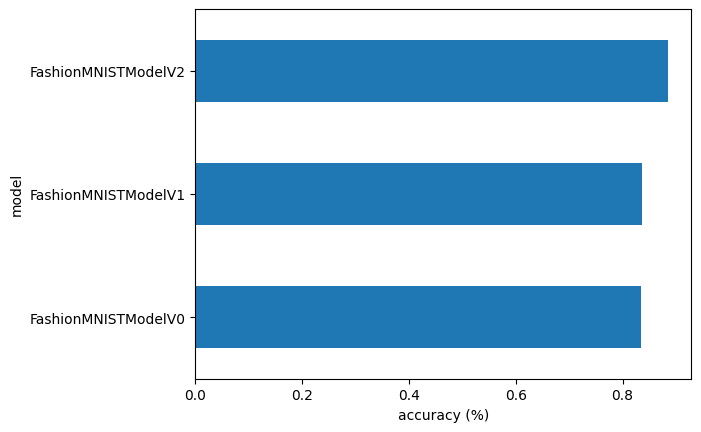

In [ ]:
compare_results.set_index("model_name")["model_acc"].plot(kind="barh")
plt.xlabel("accuracy (%)")
plt.ylabel("model")

In [ ]:
# make predictions
torch.manual_seed(42)

def make_predictions(model: torch.nn.Module,
                    data: list,
                    device: torch.device = device):
  pred_probs = []
  model.to(device)
  model.eval()
  with torch.inference_mode():
    for sample in data:
      sample = torch.unsqueeze(sample, dim=0).to(device) # Add batch dimension
      #sample = sample.to(device)
      pred_logit = model(sample)
      pred_prob = torch.softmax(pred_logit, dim=1) # Apply softmax over class dimension

      # get pred_prob off the GPU for further calculation
      pred_probs.append(pred_prob.cpu())
  # stack the pred_preds to turn list into a single tensor
  return torch.cat(pred_probs)

import random
#random.seed(42)
test_samples = []
test_labels = []
for sample, label in random.sample(list(test_data), k=9): # get 9 random samples
  test_samples.append(sample)
  test_labels.append(label)

# test_samples[0]. shape

# plt.imshow(test_samples[0].squeeze(), cmap="gray")
# plt.title(class_names[test_labels[0]])

pred_probs = make_predictions(model=model_2,
                              data=test_samples)
pred_probs[:2]

# convert prediction probabilities to labels
pred_classes = torch.argmax(pred_probs, dim=1)
pred_classes

tensor([9, 2, 1, 3, 1, 7, 2, 8, 6])

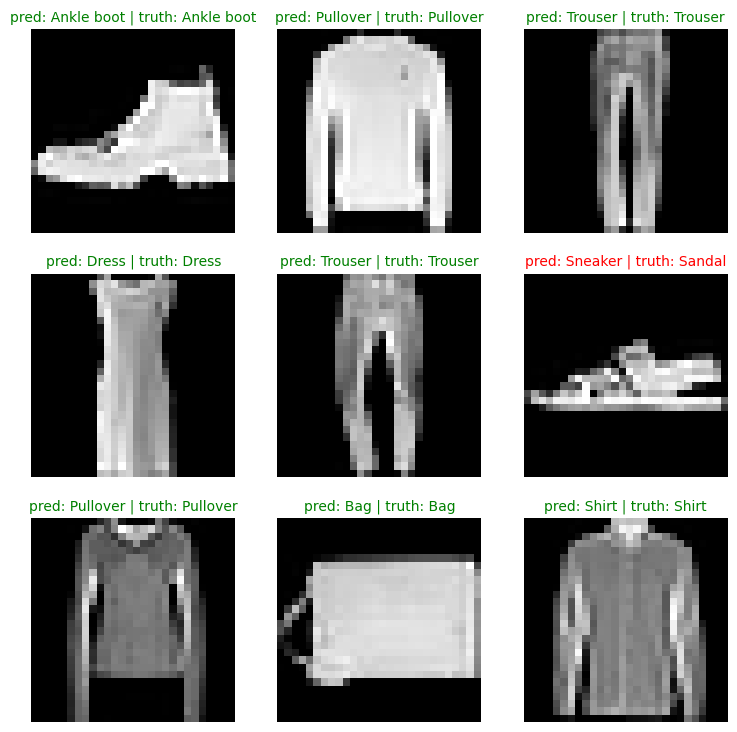

In [ ]:
# plot predictions
plt.figure(figsize=(9, 9))
nrows = 3
ncols = 3
for i, sample in enumerate(test_samples):
  plt.subplot(nrows, ncols, i+1)

  plt.imshow(sample.squeeze(), cmap="gray")

  pred_label = class_names[pred_classes[i]]
  truth_label = class_names[test_labels[i]]

  title_text = f"pred: {pred_label} | truth: {truth_label}"

  if pred_label == truth_label:
    plt.title(title_text, fontsize=10, color="green")
  else:
    plt.title(title_text, fontsize=10, color="red")

  plt.axis(False)


Making Predictions ...:   0%|          | 0/313 [00:00<?, ?it/s]

tensor([9, 2, 1, 1, 6, 1, 4, 6, 5, 7])
tensor([9, 2, 1, 1, 6, 1, 4, 6, 5, 7])
tensor([[896,   2,  16,  50,   6,   2,  24,   0,   4,   0],
        [  2, 974,   0,  17,   4,   0,   2,   0,   1,   0],
        [ 23,   1, 847,  13,  87,   0,  28,   0,   1,   0],
        [ 25,   7,   7, 919,  25,   0,  14,   0,   2,   1],
        [  2,   1,  66,  38, 850,   0,  42,   0,   1,   0],
        [  0,   0,   0,   1,   0, 973,   0,  21,   0,   5],
        [219,   2, 107,  38, 109,   0, 515,   0,  10,   0],
        [  0,   0,   0,   0,   0,  16,   0, 972,   0,  12],
        [  5,   1,   2,   6,   6,   3,   3,   6, 968,   0],
        [  0,   0,   0,   0,   0,   8,   1,  57,   1, 933]], device='cuda:0')


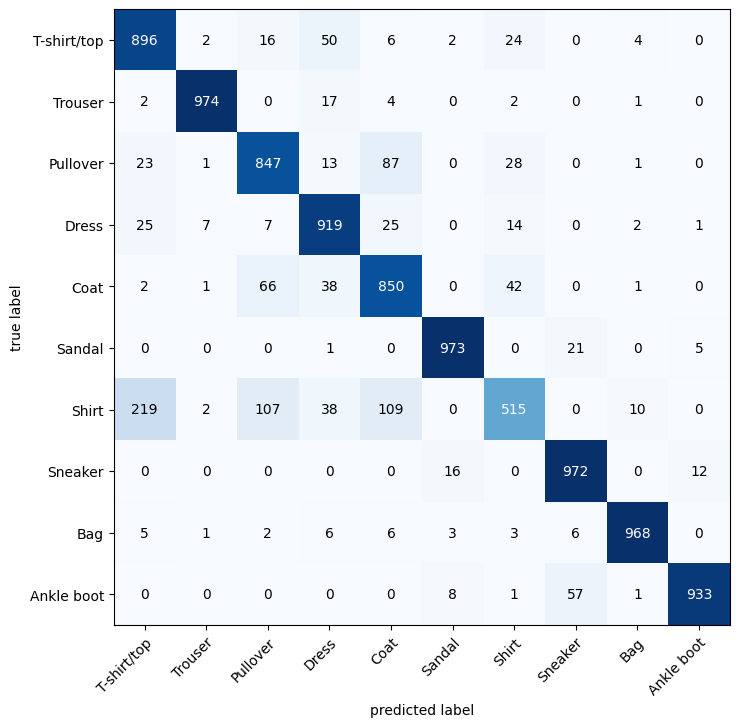

In [ ]:
# confusion matrix - another way of evaluating classification models
# leverage torchmetrix.ConfusionMatrix
# plot it using "mlxtend.plot_confusion_matrix()"

from tqdm.auto import tqdm

y_preds = []
y_true = []
model_2.eval()
with torch.inference_mode():
  for X, y in tqdm(test_dataloader, desc="Making Predictions ..."):
    X, y = X.to(device), y.to(device)
    test_logits = model_2(X)
    test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)
    y_preds.append(test_pred.cpu())
    y_true.append(y.cpu())

#print(y_preds[:2])
# concactenate list of predictions/tensors into a single tensor
y_pred_tensor = torch.cat(y_preds)
y_true_tensor = torch.cat(y_true)
print(y_pred_tensor[:10])
print(y_true_tensor[:10])
#print(y_true[:2])


import mlxtend
#mlxtend.__version__

from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

cm = ConfusionMatrix(task="multiclass", num_classes=len(class_names)).to(device)
cm_tensor = cm(preds=y_pred_tensor.to(device), target=y_true_tensor.to(device)) #target=test_data.targets
print(cm_tensor)

# plot confusion matrix
fig, ax = plot_confusion_matrix(
    conf_mat=cm_tensor.cpu().numpy(),
    class_names = class_names,
    #show_normed=True,
    cmap="Blues",
    figsize=(8, 8)
)

In [ ]:
# save and load the model

from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "03_pytorch_computer_vision_model_2.pth"
MODEl_SAVE_PATH = MODEL_PATH / MODEL_NAME

print(f"saving model to: {MODEl_SAVE_PATH}")
torch.save(obj=model_2.state_dict(),
           f=MODEl_SAVE_PATH)

saving model to: models/03_pytorch_computer_vision_model_2.pth


In [ ]:
# create a new instance of the model
torch.manual_seed(42)

loaded_model_2 = FashionMNISTModelV2(input_shape=1,
                                     hidden_units=10,
                                     output_shape=len(class_names))
loaded_model_2.load_state_dict(torch.load(f=MODEl_SAVE_PATH))
loaded_model_2.to(device)

# evaluate the loaded model
loaded_model_2_results = eval_model(
    model=loaded_model_2,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn,
    device=device
)
loaded_model_2_results

torch.isclose(torch.tensor(loaded_model_2_results["model_loss"]),
              torch.tensor(model_2_results["model_loss"]),
              atol=0.0001)


  0%|          | 0/313 [00:00<?, ?it/s]

tensor(True)